In [8]:
# !pip install pmdarima

In [9]:
# !pip install "numpy<2"

In [10]:
import pmdarima as pm

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import KNeighborsRegressor

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import classification_report
from sklearn.metrics import precision_score
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import confusion_matrix

from numpy.linalg import eig


In [12]:
from pmdarima import auto_arima

In [13]:
df_t = pd.read_csv('MaunaLoaDailyTemps-1.csv')

In [14]:
df_t.describe()

,MinTemp,MaxTemp,AvgTemp,Sunrise,Sunset
count,1821.000000,1821.000000,1821.000000,1825.000000,1825.000000
mean,38.637013,54.515102,46.818781,607.074521,1823.002740
std,3.798284,5.013654,4.143192,40.797585,49.555065
min,22.000000,36.000000,31.000000,543.000000,1742.000000
25%,36.000000,52.000000,44.000000,557.000000,1802.000000
50%,39.000000,55.000000,47.000000,614.000000,1831.000000
75%,41.000000,58.000000,50.000000,640.000000,1851.000000
max,49.000000,67.000000,57.000000,700.000000,1905.000000


In [15]:
df_t.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1825 entries, 0 to 1824
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   DATE     1825 non-null   object 
 1   MinTemp  1821 non-null   float64
 2   MaxTemp  1821 non-null   float64
 3   AvgTemp  1821 non-null   float64
 4   Sunrise  1825 non-null   int64  
 5   Sunset   1825 non-null   int64  
dtypes: float64(3), int64(2), object(1)
memory usage: 85.7+ KB


In [16]:
# df_t['year'] =
# df_t['DATE'].str.split('/').apply(lambda a: a[2])
# df_t['DATE'].str.split('/').str[2]
# pd.to_datetime(df_t['DATE']).dt.year
df_t[df_t['AvgTemp'] > 50].groupby(by=pd.to_datetime(df_t['DATE']).dt.year).count()

,DATE,MinTemp,MaxTemp,AvgTemp,Sunrise,Sunset
DATE,,,,,,
2014,65,65,65,65,65,65
2015,68,68,68,68,68,68
2016,65,65,65,65,65,65
2017,80,80,80,80,80,80
2018,53,53,53,53,53,53


<Axes: >

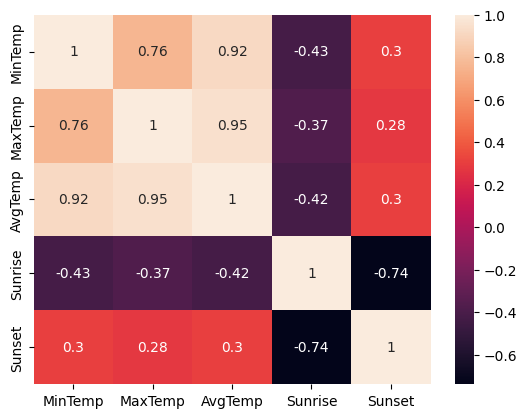

In [17]:
sns.heatmap(df_t.iloc[:,1:].corr(), annot=True,)

In [18]:
df_t['date'] = pd.to_datetime(df_t['DATE'])
del df_t['DATE']

In [19]:
df_t.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1825 entries, 0 to 1824
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   MinTemp  1821 non-null   float64       
 1   MaxTemp  1821 non-null   float64       
 2   AvgTemp  1821 non-null   float64       
 3   Sunrise  1825 non-null   int64         
 4   Sunset   1825 non-null   int64         
 5   date     1825 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(3), int64(2)
memory usage: 85.7 KB


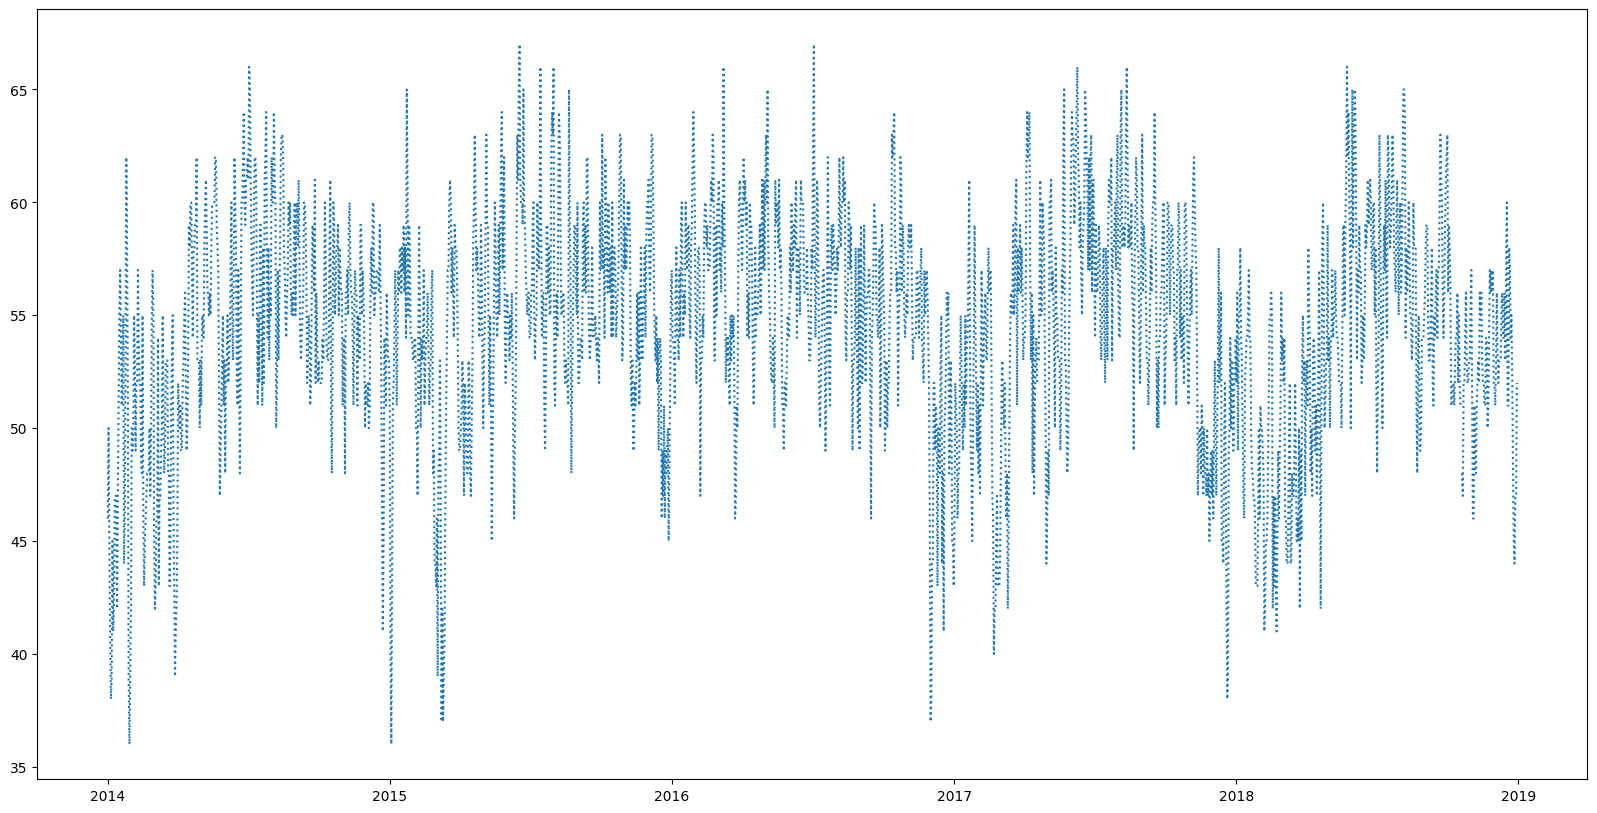

In [20]:
plt.figure(figsize=(20,10))
plt.plot(df_t.iloc[:,-1], df_t['MaxTemp'], ls=':')

plt.show()

In [21]:
# check data sort by date
(df_t.sort_values(by=['date']) == df_t).all()

,0
MinTemp,False
MaxTemp,False
AvgTemp,False
Sunrise,True
Sunset,True
date,True


In [22]:
# df_t[df_t.isnull().any(axis=1)] =
# fill na values with median of the month.
df_t = df_t.dropna(how='any', axis=0)
df_t.shape


(1821, 6)

In [23]:
# df_t =

In [24]:
df_t_rm = df_t.iloc[:,:-1].rolling(window=60).mean()
df_t_rstd = df_t.iloc[:, :-1].rolling(window=60).std()

In [25]:
df_t_rm['AvgTemp']

,AvgTemp
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
1820,45.316667
1821,45.183333
1822,45.083333
1823,44.966667


In [26]:
#plot all 3: data, rolling mean, rolling standard deviation for AvgTemp

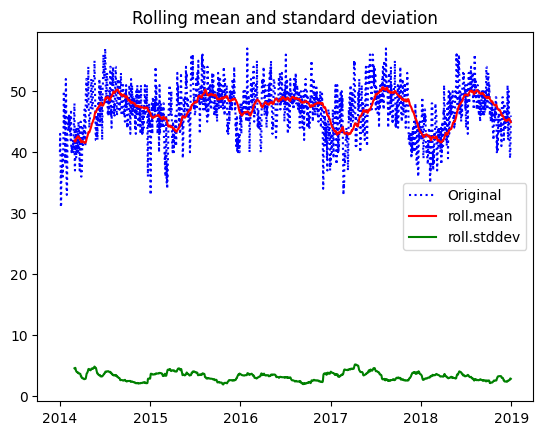

In [27]:
plt.plot(df_t['date'], df_t['AvgTemp'], 'b:', label='Original')
plt.plot(df_t['date'], df_t_rm['AvgTemp'], 'r', label='roll.mean')
plt.plot(df_t['date'], df_t_rstd['AvgTemp'], 'g', label='roll.stddev')
plt.legend(loc='center right') # best
plt.title('Rolling mean and standard deviation')
plt.show()

In [28]:
from statsmodels.tsa.stattools import adfuller

In [29]:
adfuller(df_t['AvgTemp'])[1]

8.675937480199653e-09

In [30]:
df_t_log = np.log(df_t.iloc[:, :-1]) # Loggrithm (or power) transformation removes the variance
df_t_log

,MinTemp,MaxTemp,AvgTemp,Sunrise,Sunset
0,3.496508,3.828641,3.688879,6.487684,7.470794
1,3.555348,3.912023,3.761200,6.487684,7.470794
2,3.583519,3.806662,3.713572,6.487684,7.471363
3,3.465736,3.713572,3.610918,6.489205,7.471363
4,3.178054,3.637586,3.433987,6.489205,7.471932
...,...,...,...,...,...
1820,3.555348,3.806662,3.688879,6.483107,7.468513
1821,3.496508,3.784190,3.663562,6.484635,7.468513
1822,3.496508,3.850148,3.688879,6.484635,7.469084
1823,3.583519,3.850148,3.737670,6.484635,7.469084


In [31]:
df_log_mean = df_t_log.rolling(window=60).mean()
df_log_std = df_t_log.rolling(window=60).std()


In [32]:
print(df_log_mean)
df_log_std

       MinTemp   MaxTemp   AvgTemp   Sunrise    Sunset
0          NaN       NaN       NaN       NaN       NaN
1          NaN       NaN       NaN       NaN       NaN
2          NaN       NaN       NaN       NaN       NaN
3          NaN       NaN       NaN       NaN       NaN
4          NaN       NaN       NaN       NaN       NaN
...        ...       ...       ...       ...       ...
1820  3.610429  3.970222  3.811866  6.457588  7.464680
1821  3.606811  3.967438  3.808756  6.458449  7.464699
1822  3.604460  3.965435  3.806427  6.459311  7.464728
1823  3.601115  3.963433  3.803858  6.460172  7.464766
1824  3.599488  3.962498  3.802805  6.461033  7.464814

[1821 rows x 5 columns]


,MinTemp,MaxTemp,AvgTemp,Sunrise,Sunset
0,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...
1820,0.080452,0.058121,0.060835,0.015854,0.001651
1821,0.080616,0.062854,0.063553,0.015896,0.001689
1822,0.081752,0.064650,0.065348,0.015891,0.001748
1823,0.078307,0.066336,0.064963,0.015838,0.001818


/tmp/ipython-input-4218395543.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='best')


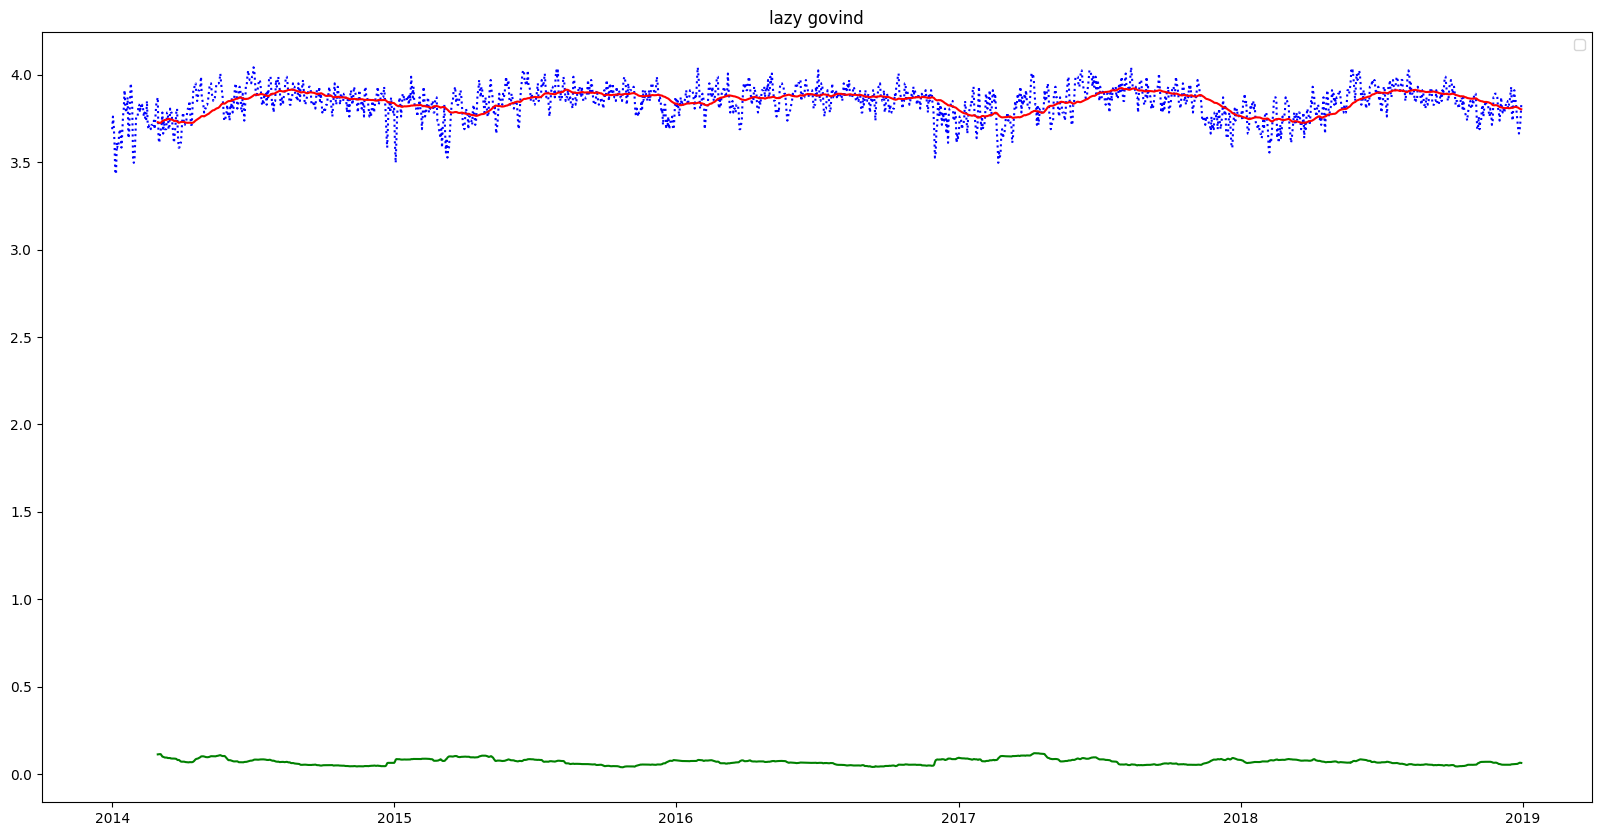

In [33]:
plt.figure(figsize=(20,10))
plt.plot(df_t['date'], df_t_log['AvgTemp'], 'b:')
plt.plot(df_t['date'], df_log_mean['AvgTemp'], 'r')
plt.plot(df_t['date'], df_log_std['AvgTemp'], 'g')
plt.legend(loc='best')
plt.title('lazy govind')
plt.show()

In [34]:
# There is no trend seen (so no need to stabilize the mean), not require mean differencing.
# data = df_log_mean['AvgTemp'] - df_log_mean['AvgTemp'].mean()
# data.dropna()

In [35]:
adfuller(df_t_log['AvgTemp'])[1]

6.550935867317728e-09

In [36]:
from statsmodels.tsa.stattools import adfuller

In [37]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [38]:
df_t_log = df_t_log.set_index(df_t['date'])


In [64]:
# df_t_log.index
df_t_log

DatetimeIndex(['2014-01-01', '2014-01-02', '2014-01-03', '2014-01-04',
               '2014-01-05', '2014-01-06', '2014-01-07', '2014-01-08',
               '2014-01-09', '2014-01-10',
               ...
               '2018-12-21', '2018-12-22', '2018-12-23', '2018-12-24',
               '2018-12-25', '2018-12-26', '2018-12-27', '2018-12-28',
               '2018-12-29', '2018-12-30'],
              dtype='datetime64[ns]', name='date', length=1825, freq='D')

In [63]:
df_t_log = df_t_log.asfreq('D')

In [41]:
decompose_result = seasonal_decompose(df_t_log['AvgTemp'], period=365)

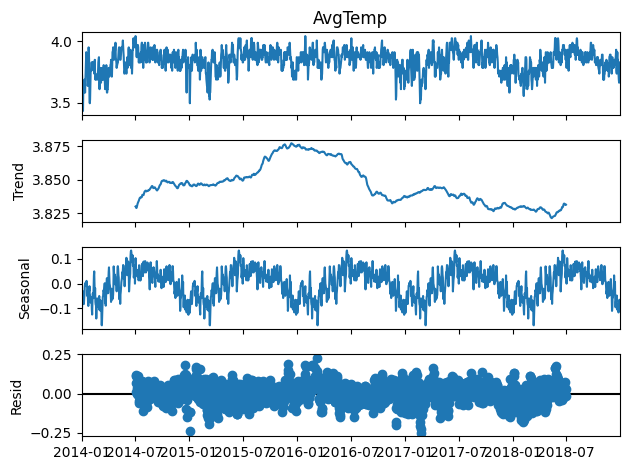

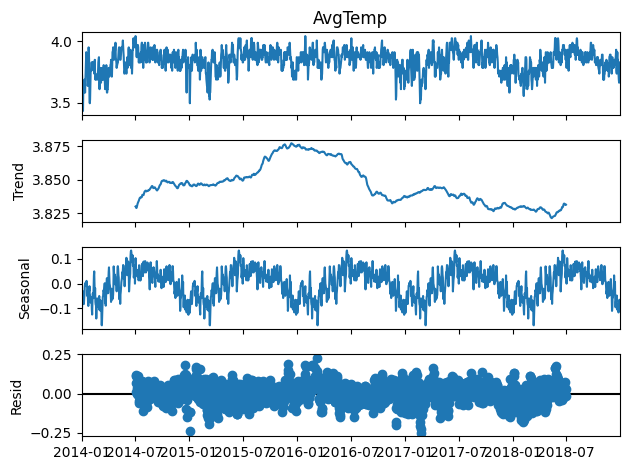

In [42]:
decompose_result.plot()

In [45]:
df_t_log['AvgTemp'] = df_t_log['AvgTemp'] - df_t_log['AvgTemp'].mean()

In [46]:
# after mean differencing , since seen tren/cyclic in decomposition
decompose_result = seasonal_decompose(df_t_log['AvgTemp'], period=365)

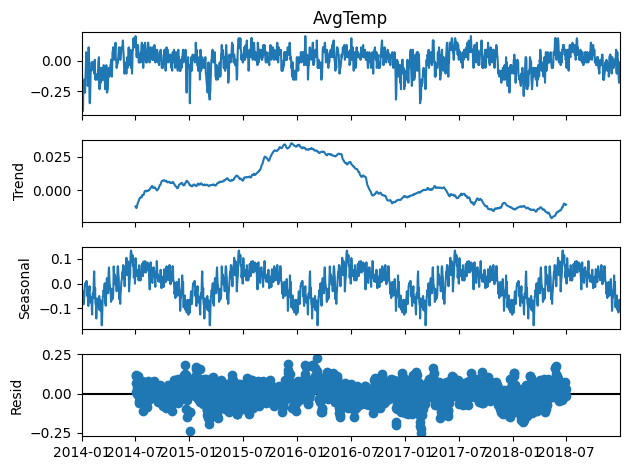

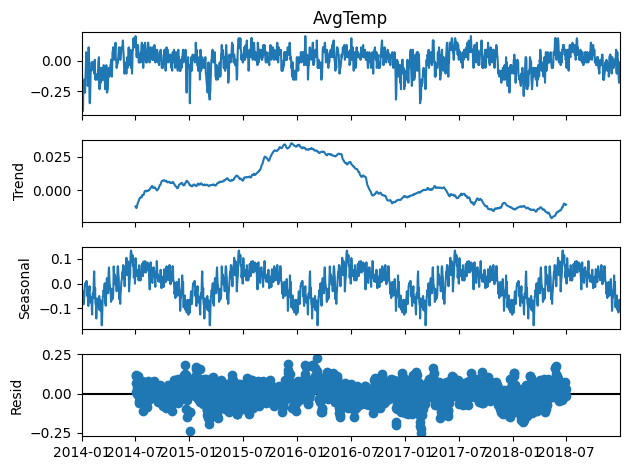

In [47]:
decompose_result.plot()

In [ ]:
import pmdarima as pm

In [65]:
model_arima = pm.auto_arima(df_t_log['AvgTemp'], seasonal=True, trace=True)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


ValueError: Input y contains NaN.

In [51]:
from statsmodels.tsa.arima.model import ARIMA

In [68]:
train = df_t_log['AvgTemp'][:6400]
test = df_t_log['AvgTemp'][6401:]

In [74]:
model_arima2 = ARIMA(train, order=(1,0,5))

In [76]:
model_arima2_fit = model_arima2.fit()

/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [73]:
model_arima2_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                AvgTemp   No. Observations:                 1825
Model:                 ARIMA(1, 0, 1)   Log Likelihood                2788.229
Date:                Tue, 05 Aug 2025   AIC                          -5568.457
Time:                        18:02:26   BIC                          -5546.420
Sample:                    01-01-2014   HQIC                         -5560.328
                         - 12-30-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0003      0.007     -0.049      0.961      -0.013       0.012
ar.L1          0.7812      0.017     46.206      0.000       0.748       0.814
ma.L1          0.1100      0.026      4.243      0.000       0.059       0.161
sigma2         0.0027   7.39e-05     36.978      0.000       0.003       0.003
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):               184.56
Prob(Q):                              0.98   Prob(JB):                         0.00
Heteroskedasticity (H):               0.79   Skew:                            -0.47
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.24
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""